
 Import Libraries
 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is often useful even if not strictly required

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure settings
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid') # Use a nice style for plots
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

import warnings
warnings.filterwarnings('ignore')


 Load and Initial Data Inspection
 

In [5]:
# Load the dataset
df = pd.read_csv('House_data.csv') 

# Display basic info
print("Dataset Info:\n")
df.info()


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
print("\nFirst 5 Rows:")
display(df.head())



First 5 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
print("\nSummary Statistics:")
display(df.describe())



Summary Statistics:


,price,area,bedrooms,bathrooms,stories,parking
count,545.000,545.000,545.000,545.000,545.000,545.000
mean,4766729.248,5150.541,2.965,1.286,1.806,0.694
std,1870439.616,2170.141,0.738,0.502,0.867,0.862
min,1750000.000,1650.000,1.000,1.000,1.000,0.000
25%,3430000.000,3600.000,2.000,1.000,1.000,0.000
50%,4340000.000,4600.000,3.000,1.000,2.000,0.000
75%,5740000.000,6360.000,3.000,2.000,2.000,1.000
max,13300000.000,16200.000,6.000,4.000,4.000,3.000


In [8]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [9]:
print(f"\nDataset Shape: {df.shape}")



Dataset Shape: (545, 13)



Data Preprocessing


In [14]:
feature_simple = ['area']
target = 'price'

# Prepare data for Simple Linear Regression
X_simple = df[feature_simple]
y = df[target]


In [15]:
print(f"Selected feature for Simple Regression: {feature_simple}")
print(f"Target variable: {target}")
print("\nShape of X_simple:", X_simple.shape)
print("Shape of y:", y.shape)


Selected feature for Simple Regression: ['area']
Target variable: price

Shape of X_simple: (545, 1)
Shape of y: (545,)


In [16]:
features_multiple = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

X_multiple = df[features_multiple]
# y remains the same (df[target])

print(f"\nSelected features for Multiple Regression: {features_multiple}")
print("\nShape of X_multiple:", X_multiple.shape)
print("Shape of y:", y.shape)



Selected features for Multiple Regression: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

Shape of X_multiple: (545, 5)
Shape of y: (545,)


In [18]:
print("\nNote: Categorical features (e.g., 'mainroad', 'guestroom') were not included in this basic model.")
print("\nThey would require encoding (like mapping 'yes'/'no' to 1/0 or One-Hot Encoding) to be used.")



Note: Categorical features (e.g., 'mainroad', 'guestroom') were not included in this basic model.

They would require encoding (like mapping 'yes'/'no' to 1/0 or One-Hot Encoding) to be used.



Split Data into Train and Test Sets


In [21]:
# --- Splitting for SIMPLE Linear Regression ---
# Uses X_simple (containing 'area') and y ('price') defined in the previous cell
X_train_simple, X_test_simple, y_train, y_test =  train_test_split( 
    X_simple, y, test_size=0.2, random_state=42 )


In [25]:
print("--- Simple Regression Shapes ---\n")
print("X_train_simple:", X_train_simple.shape)
print("X_test_simple:", X_test_simple.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


--- Simple Regression Shapes ---

X_train_simple: (436, 1)
X_test_simple: (109, 1)
y_train: (436,)
y_test: (109,)


In [26]:
# --- Splitting for MULTIPLE Linear Regression ---
# Uses X_multiple (containing 'area', 'bedrooms', etc.) and y ('price') defined in the previous cell
X_train_multiple, X_test_multiple, y_train_multi, y_test_multi = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)
# Let's reuse y_train and y_test for consistency, as they come from the same split of y
# y_train = y_train_multi <--- No, use the original y_train/y_test from the simple split for consistency
# y_test = y_test_multi  <--- as long as random_state is the same, they are identical


In [27]:
print("--- Multiple Regression Shapes ---\n")
print("X_train_multiple:", X_train_multiple.shape)
print("X_test_multiple:", X_test_multiple.shape)
print("y_train:", y_train.shape) # Reusing y_train from simple split
print("y_test:", y_test.shape)   # Reusing y_test from simple split


--- Multiple Regression Shapes ---

X_train_multiple: (436, 5)
X_test_multiple: (109, 5)
y_train: (436,)
y_test: (109,)



Fit Linear Regression Model


In [29]:
# --- Simple Linear Regression ---
print("--- Training Simple Linear Regression ---\n")
model_simple = LinearRegression()
# Fit using the training data created in the previous cell
model_simple.fit(X_train_simple, y_train)
print("Simple Linear Regression model trained successfully.")


--- Training Simple Linear Regression ---

Simple Linear Regression model trained successfully.


In [32]:
# --- Multiple Linear Regression ---
print("--- Training Multiple Linear Regression ---\n")
model_multiple = LinearRegression()
# Fit using the multiple features training set created previously
model_multiple.fit(X_train_multiple, y_train)
print("Multiple Linear Regression model trained successfully.")

--- Training Multiple Linear Regression ---

Multiple Linear Regression model trained successfully.



Evaluate Models


In [35]:
# --- Evaluate Simple Linear Regression ---
print("--- Simple Linear Regression Evaluation (using 'area') ---\n")
# Predict on the simple test set
y_pred_simple = model_simple.predict(X_test_simple)

# Calculate metrics comparing actual test prices (y_test) vs predicted prices (y_pred_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple) # Root Mean Squared Error
r2_simple = r2_score(y_test, y_pred_simple)

print(f"Mean Absolute Error (MAE): {mae_simple:,.2f}")
print(f"Mean Squared Error (MSE): {mse_simple:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_simple:,.2f}")
print(f"R-squared (R²): {r2_simple:.4f}")


--- Simple Linear Regression Evaluation (using 'area') ---

Mean Absolute Error (MAE): 1,474,748.13
Mean Squared Error (MSE): 3,675,286,604,768.19
Root Mean Squared Error (RMSE): 1,917,103.70
R-squared (R²): 0.2729


In [37]:
# --- Evaluate Multiple Linear Regression ---
print("--- Multiple Linear Regression Evaluation ---\n")
# Predict using the multiple regression model on its corresponding test set
y_pred_multiple = model_multiple.predict(X_test_multiple)

# Calculate metrics comparing actual test prices (y_test) vs predicted prices (y_pred_multiple)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple) # Compare against the same y_test
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f"Mean Absolute Error (MAE): {mae_multiple:,.2f}")
print(f"Mean Squared Error (MSE): {mse_multiple:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_multiple:,.2f}")
print(f"R-squared (R²): {r2_multiple:.4f}")


--- Multiple Linear Regression Evaluation ---

Mean Absolute Error (MAE): 1,127,483.35
Mean Squared Error (MSE): 2,292,721,545,725.36
Root Mean Squared Error (RMSE): 1,514,173.55
R-squared (R²): 0.5464


In [41]:
# Compare R² scores
print(f"Comparison: \n Simple R² = {r2_simple:.4f}, \n Multiple R² = {r2_multiple:.4f}")
if r2_multiple > r2_simple:
    print("Multiple Regression explains more variance in the price.")
else:
    print("Multiple Regression does not explain significantly more variance than Simple Regression (using only 'area').")
    

Comparison: 
 Simple R² = 0.2729, 
 Multiple R² = 0.5464
Multiple Regression explains more variance in the price.



Interpret Coefficients and Plot


In [43]:
# --- Interpret Simple Linear Regression (using 'area') ---
print("--- Simple Linear Regression Interpretation ('area') ---\n ")
simple_intercept = model_simple.intercept_
simple_coefficient = model_simple.coef_[0] # Get the coefficient for 'area'

print(f"Intercept (Estimated base price): ${simple_intercept:,.2f}")
print(f"Coefficient for '{feature_simple[0]}': {simple_coefficient:,.2f}") # Use feature_simple[0] which is 'area'
print(f"Interpretation: For each 1 unit increase in '{feature_simple[0]}', the predicted price increases by approximately ${simple_coefficient:,.2f}.")


--- Simple Linear Regression Interpretation ('area') ---
 
Intercept (Estimated base price): $2,512,254.26
Coefficient for 'area': 425.73
Interpretation: For each 1 unit increase in 'area', the predicted price increases by approximately $425.73.


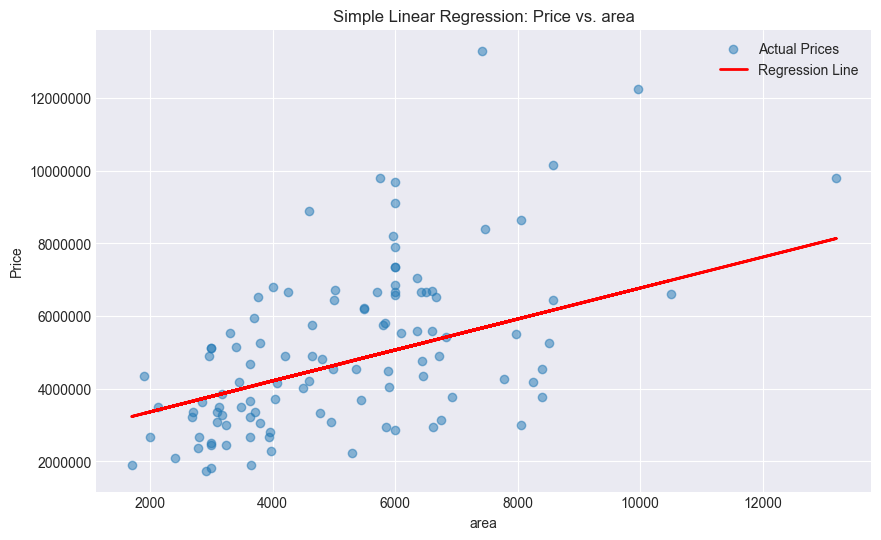

In [44]:
# --- Plot Simple Linear Regression ---
plt.figure(figsize=(10, 6))
# Scatter plot of actual test data points (area vs price)
plt.scatter(X_test_simple, y_test, alpha=0.5, label='Actual Prices')
# Plot the regression line (predicted prices for the test areas)
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.title(f'Simple Linear Regression: Price vs. {feature_simple[0]}') # Updated title
plt.xlabel(feature_simple[0]) # Updated x-axis label
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()


In [45]:
# --- Interpret Multiple Linear Regression ---
print("--- Multiple Linear Regression Interpretation ---\n")
multiple_intercept = model_multiple.intercept_
multiple_coefficients = model_multiple.coef_

print(f"Intercept (Estimated base price): ${multiple_intercept:,.2f}")
# Create a DataFrame using the correct feature names from 'features_multiple'
coeffs = pd.DataFrame(multiple_coefficients, index=features_multiple, columns=['Coefficient'])
print("\nCoefficients for Features:")
display(coeffs.sort_values('Coefficient', ascending=False))



--- Multiple Linear Regression Interpretation ---
Intercept (Estimated base price): $51,999.68

Coefficients for Features:


,Coefficient
bathrooms,1185731.714
stories,495100.763
parking,337660.830
bedrooms,151246.751
area,308.867


In [46]:
print("\nInterpretation Examples:")
# Use .loc to access coefficients by name, ensure names match 'features_multiple'
if 'area' in coeffs.index:
    print(f"- For each 1 unit increase in 'area', the predicted price changes by ${coeffs.loc['area'].values[0]:,.2f}, holding all other listed features constant.")
if 'bedrooms' in coeffs.index:
    print(f"- For each 1 unit increase in 'bedrooms', the predicted price changes by ${coeffs.loc['bedrooms'].values[0]:,.2f}, holding all other listed features constant.")
if 'bathrooms' in coeffs.index:
    print(f"- For each 1 unit increase in 'bathrooms', the predicted price changes by ${coeffs.loc['bathrooms'].values[0]:,.2f}, holding all other listed features constant.")
# Add interpretations for 'stories' and 'parking' if desired.



Interpretation Examples:
- For each 1 unit increase in 'area', the predicted price changes by $308.87, holding all other listed features constant.
- For each 1 unit increase in 'bedrooms', the predicted price changes by $151,246.75, holding all other listed features constant.
- For each 1 unit increase in 'bathrooms', the predicted price changes by $1,185,731.71, holding all other listed features constant.


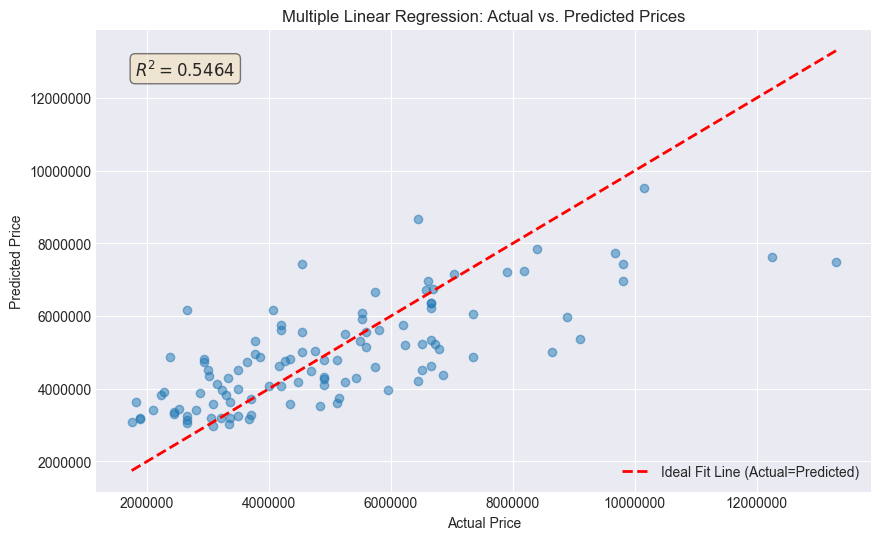

In [47]:
# --- Plot Multiple Linear Regression Results ---
# Plot Actual vs. Predicted values. This plot works regardless of the number of features.
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_multiple, alpha=0.5)
# Plot the ideal line where Actual = Predicted
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='red', label='Ideal Fit Line (Actual=Predicted)')
plt.title('Multiple Linear Regression: Actual vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
# Add R² score text to the plot
plt.text(0.05, 0.9, f'$R^2 = {r2_multiple:.4f}$', transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
plt.show()


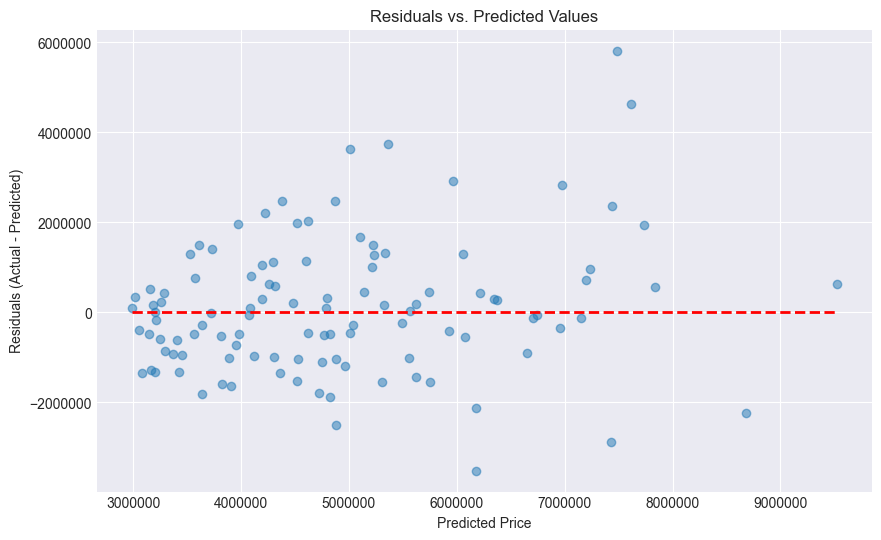

In [48]:
# Plot Residuals (Errors = Actual - Predicted) vs. Predicted Values
residuals = y_test - y_pred_multiple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multiple, residuals, alpha=0.5)
# Add a horizontal line at zero error
plt.hlines(0, xmin=y_pred_multiple.min(), xmax=y_pred_multiple.max(), colors='red', linestyles='--', lw=2)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.ticklabel_format(style='plain', axis='y')
plt.ticklabel_format(style='plain', axis='x')
plt.show()
